# 111 - 厳密 kNN vs Voronoi: テキスト→画像検索

## 目的

NB105-106 では Voronoi 分割の性能をブルートフォース（= 厳密 kNN）と比較したが、
ここではその比較を **NB107 で学習済みのピボット** を使って正式に行う。

### 実験設計
- **モデル**: SigLIP 2 Large (1024-D)
- **データ**: カタログ 378 件 + pyconjp 23,086 件 = 23,464 件
- **ピボット**: NB107 学習済み 256 ピボット（`voronoi_pivots_siglip2_large.npy`）
- **クエリ**: 18 テキストクエリ (12 EN + 6 JA)
- **核心指標**: MRR_ratio = Voronoi MRR / 厳密 kNN MRR

### NB105 との違い
- NB105: ピボットを都度 k-means で学習 → パラメータスイープ
- NB111: NB107 の事前学習済みピボットを使用（実運用想定）

In [1]:
import sys
sys.path.insert(0, '../src')

import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PYCONJP_DB_PATH = Path('/home/terapyon/dev/vibe-coding/pyconjp-image-search/pyconjp_image_search_siglip2_large.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots_siglip2_large.npy')
PYTHON_MODEL = 'google/siglip2-large-patch16-256'
RANDOM_STATE = 42
N_PIVOTS = 256

## 1. データ読み込み

In [2]:
# カタログ画像
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
catalog_rows = conn.execute("""
    SELECT e.id, e.embedding, c.category
    FROM image_embeddings_1024 e
    JOIN image_catalog c ON e.id = c.id
    WHERE e.model_name = ?
    ORDER BY c.category
""", [PYTHON_MODEL]).fetchall()
conn.close()

# pyconjp 画像
conn_pj = duckdb.connect(str(PYCONJP_DB_PATH), read_only=True)
pyconjp_rows = conn_pj.execute("""
    SELECT i.id, e.embedding, i.event_name
    FROM image_embeddings e
    JOIN images i ON e.image_id = i.id
    WHERE e.model_name = ?
    ORDER BY i.id
""", [PYTHON_MODEL]).fetchall()
conn_pj.close()

# 統合・正規化
all_ids = [r[0] for r in catalog_rows] + [r[0] for r in pyconjp_rows]
all_embeddings = np.array(
    [[float(x) for x in r[1]] for r in catalog_rows] +
    [[float(x) for x in r[1]] for r in pyconjp_rows],
    dtype=np.float32
)
all_categories = [r[2] for r in catalog_rows] + ['pyconjp'] * len(pyconjp_rows)

norms = np.linalg.norm(all_embeddings, axis=1, keepdims=True)
all_embeddings_normed = all_embeddings / norms

N_IMAGES = len(all_ids)
N_CATALOG = len(catalog_rows)
N_PYCONJP = len(pyconjp_rows)

# 事前学習済みピボット読み込み
centroids_normed = np.load(PIVOT_PATH)
print(f'総画像数: {N_IMAGES} (カタログ: {N_CATALOG}, pyconjp: {N_PYCONJP})')
print(f'埋め込み次元: {all_embeddings.shape[1]}')
print(f'ピボット: {centroids_normed.shape} (from NB107)')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

総画像数: 23464 (カタログ: 378, pyconjp: 23086)
埋め込み次元: 1024
ピボット: (256, 1024) (from NB107)


In [3]:
# テキスト埋め込み生成
import torch
from image_vector_poc import SigLIP2Embedder

test_queries = [
    {'query': 'a park with trees and nature', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'village park with greenery', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'night cityscape Tokyo', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'city lights at night', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'Python conference presentation', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'conference hall with audience', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'speaker giving a talk', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'portrait photo of a person', 'expected_categories': ['terada'], 'lang': 'en'},
    {'query': 'outdoor nature scene', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'en'},
    {'query': 'urban night photography', 'expected_categories': ['TokyoNight202505'], 'lang': 'en'},
    {'query': 'tech conference event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': 'people at an event', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'en'},
    {'query': '公園の自然風景', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '東京の夜景', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
    {'query': 'カンファレンスの講演', 'expected_categories': ['EuroPython2025', 'PyConJP2025', 'PyConJP2025-PreCampHiroshima'], 'lang': 'ja'},
    {'query': '人物の写真', 'expected_categories': ['terada'], 'lang': 'ja'},
    {'query': '緑の木々', 'expected_categories': ['KashiwaVillagePark2026'], 'lang': 'ja'},
    {'query': '夜の街', 'expected_categories': ['TokyoNight202505'], 'lang': 'ja'},
]

embedder = SigLIP2Embedder(model_name=PYTHON_MODEL, device='cuda')
text_embeddings = embedder.embed_texts([q['query'] for q in test_queries])
text_norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
text_embeddings_normed = text_embeddings / text_norms
n_queries = len(test_queries)

del embedder
torch.cuda.empty_cache()
print(f'テストクエリ数: {n_queries} (EN: {sum(1 for q in test_queries if q["lang"] == "en")}, JA: {sum(1 for q in test_queries if q["lang"] == "ja")})')

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


テストクエリ数: 18 (EN: 12, JA: 6)


## 2. 厳密 kNN ベースライン

In [4]:
# 厳密 kNN（ブルートフォース）
TOP_K_VALUES = [5, 10, 20]
MAX_K = max(TOP_K_VALUES)

t0 = time.perf_counter()
bf_results = []
for qi, q in enumerate(test_queries):
    text_emb = text_embeddings_normed[qi]
    sims = all_embeddings_normed @ text_emb
    top_indices = np.argsort(-sims)[:MAX_K]
    result_cats = [all_categories[idx] for idx in top_indices]
    is_relevant = [cat in q['expected_categories'] for cat in result_cats]

    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break

    recall = {}
    total_relevant = sum(1 for c in all_categories if c in q['expected_categories'])
    for k in TOP_K_VALUES:
        recall[k] = sum(is_relevant[:k]) / min(k, total_relevant) if total_relevant > 0 else 0.0

    bf_results.append({
        'query': q['query'], 'lang': q['lang'],
        'top_indices': top_indices.tolist(),
        'top_sims': sims[top_indices].tolist(),
        'top_cats': result_cats,
        'MRR': mrr,
        'P@1': sum(is_relevant[:1]),
        'P@5': sum(is_relevant[:5]) / 5,
        'P@10': sum(is_relevant[:10]) / 10,
        'Recall@10': recall[10],
        'Recall@20': recall[20],
    })

t_bf = time.perf_counter() - t0

df_bf = pd.DataFrame(bf_results)
print(f'厳密 kNN ベースライン ({N_IMAGES:,} 画像, {t_bf:.3f}s):')
print(f'  Overall MRR: {df_bf["MRR"].mean():.4f}')
print(f'  EN MRR:      {df_bf[df_bf["lang"] == "en"]["MRR"].mean():.4f}')
print(f'  JA MRR:      {df_bf[df_bf["lang"] == "ja"]["MRR"].mean():.4f}')
print(f'  P@1:         {df_bf["P@1"].mean():.4f}')
print(f'  P@5:         {df_bf["P@5"].mean():.4f}')
print(f'  P@10:        {df_bf["P@10"].mean():.4f}')
print(f'  Recall@10:   {df_bf["Recall@10"].mean():.4f}')
print(f'  Recall@20:   {df_bf["Recall@20"].mean():.4f}')

print(f'\n※ NB105 BF MRR=0.352 との一致を確認')

厳密 kNN ベースライン (23,464 画像, 0.193s):
  Overall MRR: 0.3524
  EN MRR:      0.3550
  JA MRR:      0.3472
  P@1:         0.2222
  P@5:         0.1778
  P@10:        0.1944
  Recall@10:   0.1944
  Recall@20:   0.2500

※ NB105 BF MRR=0.352 との一致を確認


In [5]:
# クエリ別詳細
print('クエリ別 厳密 kNN 結果:')
print(f'{"クエリ":<35} {"Lang":>4} {"MRR":>6} {"P@1":>4} {"P@5":>5} {"P@10":>5} {"Top-1カテゴリ"}')
print('-' * 100)
for _, row in df_bf.iterrows():
    top1_cat = row['top_cats'][0] if row['top_cats'] else '?'
    print(f'{row["query"]:<35} {row["lang"]:>4} {row["MRR"]:>6.3f} {row["P@1"]:>4.0f} {row["P@5"]:>5.2f} {row["P@10"]:>5.2f} {top1_cat}')

クエリ別 厳密 kNN 結果:
クエリ                                 Lang    MRR  P@1   P@5  P@10 Top-1カテゴリ
----------------------------------------------------------------------------------------------------
a park with trees and nature          en  0.333    0  0.20  0.40 EuroPython2025
village park with greenery            en  0.167    0  0.00  0.10 EuroPython2025
night cityscape Tokyo                 en  0.250    0  0.20  0.10 pyconjp
city lights at night                  en  0.100    0  0.00  0.10 pyconjp
Python conference presentation        en  1.000    1  0.20  0.20 EuroPython2025
conference hall with audience         en  0.077    0  0.00  0.00 pyconjp
speaker giving a talk                 en  0.000    0  0.00  0.00 pyconjp
portrait photo of a person            en  0.083    0  0.00  0.00 pyconjp
outdoor nature scene                  en  1.000    1  1.00  0.90 KashiwaVillagePark2026
urban night photography               en  0.250    0  0.20  0.40 pyconjp
tech conference event                 en  

## 3. Voronoi 検索（NB107 事前学習ピボット）

NB107 で 23,464 件の画像から学習した 256 ピボットを使用。
NB105 では都度 k-means を実行していたが、ここでは事前学習済みピボットの実運用性能を評価する。

In [6]:
N_ASSIGN_LIST = [1, 2, 3]
TOP_SEARCH_LIST = [1, 2, 3, 4, 5, 8]


def voronoi_search(image_embs, text_embs, centroids_normed, pivot_to_indices,
                   n_top, categories, test_queries, bf_results):
    """Voronoi 検索を実行し、厳密 kNN と比較する評価指標を返す。"""
    results = []
    candidate_counts = []

    for qi, q in enumerate(test_queries):
        text_emb = text_embs[qi]
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])
        candidates = list(candidates_set)
        candidate_counts.append(len(candidates))

        if not candidates:
            results.append({'MRR': 0.0, 'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0,
                            'Recall@10': 0.0, 'Recall@20': 0.0})
            continue

        cand_indices = np.array(candidates)
        cand_sims = image_embs[cand_indices] @ text_emb
        sorted_order = np.argsort(-cand_sims)
        result_indices = cand_indices[sorted_order]

        result_cats = [categories[idx] for idx in result_indices[:MAX_K]]
        is_relevant = [cat in q['expected_categories'] for cat in result_cats]

        mrr = 0.0
        for i, rel in enumerate(is_relevant):
            if rel:
                mrr = 1.0 / (i + 1)
                break

        total_relevant = sum(1 for c in categories if c in q['expected_categories'])
        recall = {}
        for k in TOP_K_VALUES:
            recall[k] = sum(is_relevant[:k]) / min(k, total_relevant) if total_relevant > 0 else 0.0

        results.append({
            'MRR': mrr,
            'P@1': sum(is_relevant[:1]) if len(is_relevant) >= 1 else 0.0,
            'P@5': sum(is_relevant[:5]) / 5 if len(is_relevant) >= 5 else sum(is_relevant) / 5,
            'P@10': sum(is_relevant[:10]) / 10 if len(is_relevant) >= 10 else sum(is_relevant) / 10,
            'Recall@10': recall[10],
            'Recall@20': recall[20],
        })

    # BF-Recall（厳密 kNN Top-K の回収率）
    bf_recall = {k: [] for k in TOP_K_VALUES}
    for qi in range(len(test_queries)):
        text_emb = text_embs[qi]
        pivot_sims = centroids_normed @ text_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        candidates_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                candidates_set.update(pivot_to_indices[int(pid)])

        if not candidates_set:
            for k in TOP_K_VALUES:
                bf_recall[k].append(0.0)
            continue

        cand_indices = np.array(list(candidates_set))
        cand_sims = image_embs[cand_indices] @ text_emb
        result_indices = cand_indices[np.argsort(-cand_sims)]

        for k in TOP_K_VALUES:
            bf_top_k = set(bf_results[qi]['top_indices'][:k])
            voronoi_top_k = set(result_indices[:k].tolist())
            bf_recall[k].append(len(bf_top_k & voronoi_top_k) / k)

    df_res = pd.DataFrame(results)
    en_idx = [i for i, q in enumerate(test_queries) if q['lang'] == 'en']
    ja_idx = [i for i, q in enumerate(test_queries) if q['lang'] == 'ja']

    return {
        'mean_candidates': np.mean(candidate_counts),
        'max_candidates': max(candidate_counts),
        'MRR': df_res['MRR'].mean(),
        'MRR_en': df_res.iloc[en_idx]['MRR'].mean(),
        'MRR_ja': df_res.iloc[ja_idx]['MRR'].mean(),
        'P@1': df_res['P@1'].mean(),
        'P@5': df_res['P@5'].mean(),
        'P@10': df_res['P@10'].mean(),
        'Recall@10': df_res['Recall@10'].mean(),
        'Recall@20': df_res['Recall@20'].mean(),
        'bf_recall': {k: np.mean(v) for k, v in bf_recall.items()},
        'per_query_mrr': df_res['MRR'].tolist(),
    }

print('検索関数定義完了')

検索関数定義完了


In [7]:
# パラメータスイープ実行
all_img_pivot_sims = all_embeddings_normed @ centroids_normed.T
all_sweep_results = {}

for n_assign in N_ASSIGN_LIST:
    print(f'\nassign={n_assign}')

    # マルチピボット割り当て
    pivot_to_indices = {}
    for i in range(N_IMAGES):
        top_pivots = np.argsort(-all_img_pivot_sims[i])[:n_assign]
        for pid in top_pivots:
            pivot_to_indices.setdefault(int(pid), []).append(i)

    for n_top in TOP_SEARCH_LIST:
        t0 = time.perf_counter()
        res = voronoi_search(
            all_embeddings_normed, text_embeddings_normed,
            centroids_normed, pivot_to_indices, n_top,
            all_categories, test_queries, bf_results
        )
        t_vor = time.perf_counter() - t0
        res['time'] = t_vor

        key = (n_assign, n_top)
        all_sweep_results[key] = res

        bf_mrr = df_bf['MRR'].mean()
        mrr_ratio = res['MRR'] / bf_mrr if bf_mrr > 0 else 0

        print(f'  a={n_assign} top={n_top}: '
              f'cands={res["mean_candidates"]:.0f} '
              f'MRR={res["MRR"]:.4f} '
              f'MRR_ratio={mrr_ratio:.4f} '
              f'BF-R@10={res["bf_recall"][10]:.4f} '
              f'({t_vor:.3f}s)')

print(f'\n総構成数: {len(all_sweep_results)}')


assign=1


  a=1 top=1: cands=52 MRR=0.2112 MRR_ratio=0.5993 BF-R@10=0.4222 (0.023s)
  a=1 top=2: cands=126 MRR=0.2817 MRR_ratio=0.7994 BF-R@10=0.6389 (0.056s)
  a=1 top=3: cands=203 MRR=0.3441 MRR_ratio=0.9764 BF-R@10=0.7278 (0.066s)
  a=1 top=4: cands=303 MRR=0.3415 MRR_ratio=0.9690 BF-R@10=0.7556 (0.060s)


  a=1 top=5: cands=401 MRR=0.3460 MRR_ratio=0.9819 BF-R@10=0.7944 (0.097s)
  a=1 top=8: cands=700 MRR=0.3655 MRR_ratio=1.0372 BF-R@10=0.8444 (0.156s)

assign=2


  a=2 top=1: cands=87 MRR=0.2163 MRR_ratio=0.6137 BF-R@10=0.4444 (0.016s)
  a=2 top=2: cands=226 MRR=0.2950 MRR_ratio=0.8371 BF-R@10=0.7000 (0.033s)
  a=2 top=3: cands=367 MRR=0.3454 MRR_ratio=0.9801 BF-R@10=0.8000 (0.090s)
  a=2 top=4: cands=515 MRR=0.3432 MRR_ratio=0.9739 BF-R@10=0.8056 (0.071s)


  a=2 top=5: cands=650 MRR=0.3428 MRR_ratio=0.9726 BF-R@10=0.8444 (0.146s)
  a=2 top=8: cands=1132 MRR=0.3626 MRR_ratio=1.0289 BF-R@10=0.8833 (0.174s)

assign=3


  a=3 top=1: cands=127 MRR=0.1599 MRR_ratio=0.4538 BF-R@10=0.4611 (0.024s)
  a=3 top=2: cands=315 MRR=0.3151 MRR_ratio=0.8942 BF-R@10=0.7667 (0.045s)
  a=3 top=3: cands=499 MRR=0.3515 MRR_ratio=0.9974 BF-R@10=0.8389 (0.043s)
  a=3 top=4: cands=677 MRR=0.3506 MRR_ratio=0.9947 BF-R@10=0.8444 (0.087s)


  a=3 top=5: cands=855 MRR=0.3528 MRR_ratio=1.0012 BF-R@10=0.8889 (0.124s)
  a=3 top=8: cands=1491 MRR=0.3528 MRR_ratio=1.0012 BF-R@10=0.9278 (0.169s)

総構成数: 18


## 4. 比較分析

In [8]:
# 厳密 kNN vs Voronoi 比較テーブル
bf_mrr = df_bf['MRR'].mean()

sweep_rows = []
for (n_assign, n_top), res in sorted(all_sweep_results.items()):
    sweep_rows.append({
        'assign': n_assign, 'search_top': n_top,
        'mean_cands': res['mean_candidates'],
        'cand_ratio': res['mean_candidates'] / N_IMAGES,
        'V_MRR': res['MRR'],
        'MRR_ratio': res['MRR'] / bf_mrr if bf_mrr > 0 else 0,
        'V_P@1': res['P@1'],
        'V_P@5': res['P@5'],
        'V_P@10': res['P@10'],
        'V_Recall@10': res['Recall@10'],
        'V_Recall@20': res['Recall@20'],
        'BF-R@10': res['bf_recall'][10],
        'time': res['time'],
    })

df_sweep = pd.DataFrame(sweep_rows)

print(f'厳密 kNN ベースライン: MRR={bf_mrr:.4f}, P@1={df_bf["P@1"].mean():.4f}, '
      f'P@10={df_bf["P@10"].mean():.4f}, time={t_bf:.3f}s')
print(f'\nVoronoi 全構成（MRR_ratio 降順）:')
display(df_sweep.sort_values('MRR_ratio', ascending=False).style.format({
    'mean_cands': '{:.0f}', 'cand_ratio': '{:.3f}',
    'V_MRR': '{:.4f}', 'MRR_ratio': '{:.4f}',
    'V_P@1': '{:.3f}', 'V_P@5': '{:.3f}', 'V_P@10': '{:.3f}',
    'V_Recall@10': '{:.4f}', 'V_Recall@20': '{:.4f}',
    'BF-R@10': '{:.4f}', 'time': '{:.3f}',
}).background_gradient(subset=['MRR_ratio'], cmap='RdYlGn', vmin=0.8, vmax=1.3))

厳密 kNN ベースライン: MRR=0.3524, P@1=0.2222, P@10=0.1944, time=0.193s

Voronoi 全構成（MRR_ratio 降順）:


,assign,search_top,mean_cands,cand_ratio,V_MRR,MRR_ratio,V_P@1,V_P@5,V_P@10,V_Recall@10,V_Recall@20,BF-R@10,time
5,1,8,700,0.030,0.3655,1.0372,0.222,0.200,0.200,0.2000,0.2500,0.8444,0.156
11,2,8,1132,0.048,0.3626,1.0289,0.222,0.189,0.200,0.2000,0.2583,0.8833,0.174
17,3,8,1491,0.064,0.3528,1.0012,0.222,0.189,0.194,0.1944,0.2528,0.9278,0.169
16,3,5,855,0.036,0.3528,1.0012,0.222,0.211,0.206,0.2056,0.2528,0.8889,0.124
14,3,3,499,0.021,0.3515,0.9974,0.222,0.211,0.206,0.2056,0.2611,0.8389,0.043
15,3,4,677,0.029,0.3506,0.9947,0.222,0.211,0.200,0.2000,0.2556,0.8444,0.087
4,1,5,401,0.017,0.3460,0.9819,0.222,0.189,0.206,0.2056,0.2444,0.7944,0.097
8,2,3,367,0.016,0.3454,0.9801,0.222,0.189,0.200,0.2000,0.2667,0.8000,0.090
2,1,3,203,0.009,0.3441,0.9764,0.222,0.178,0.194,0.1944,0.2444,0.7278,0.066
9,2,4,515,0.022,0.3432,0.9739,0.222,0.189,0.194,0.1944,0.2528,0.8056,0.071


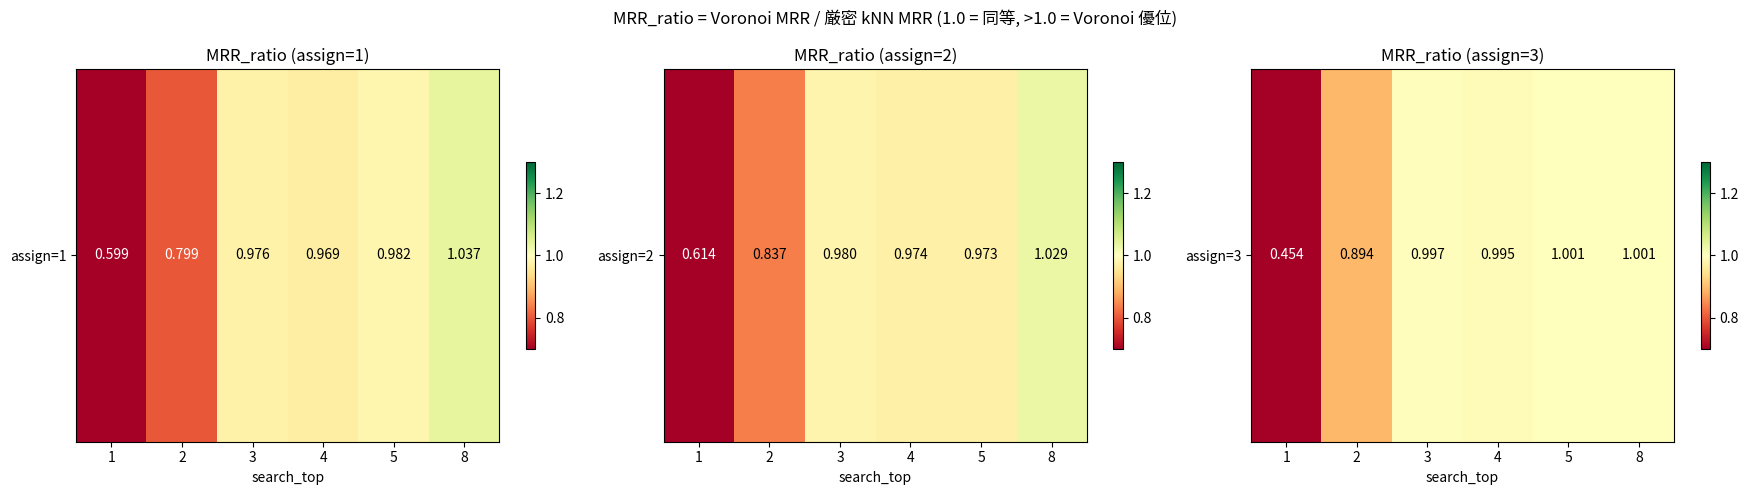

In [9]:
# ヒートマップ: assign × search_top の MRR_ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, n_assign in enumerate(N_ASSIGN_LIST):
    ax = axes[ax_idx]
    df_sub = df_sweep[df_sweep['assign'] == n_assign]
    pivot_table = df_sub.pivot_table(index='assign', columns='search_top', values='MRR_ratio')

    # 全 assign の MRR_ratio を 1 行ヒートマップとして表示
    data = []
    labels = []
    for n_top in TOP_SEARCH_LIST:
        key = (n_assign, n_top)
        if key in all_sweep_results:
            data.append(all_sweep_results[key]['MRR'] / bf_mrr if bf_mrr > 0 else 0)
            labels.append(str(n_top))

    data_2d = np.array(data).reshape(1, -1)
    im = ax.imshow(data_2d, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.3)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks([0])
    ax.set_yticklabels([f'assign={n_assign}'])
    ax.set_xlabel('search_top')
    ax.set_title(f'MRR_ratio (assign={n_assign})')

    for j, val in enumerate(data):
        color = 'white' if val > 1.1 or val < 0.8 else 'black'
        ax.text(j, 0, f'{val:.3f}', ha='center', va='center', fontsize=10, color=color)

    plt.colorbar(im, ax=ax, shrink=0.5)

plt.suptitle(f'MRR_ratio = Voronoi MRR / 厳密 kNN MRR (1.0 = 同等, >1.0 = Voronoi 優位)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/111_mrr_ratio_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

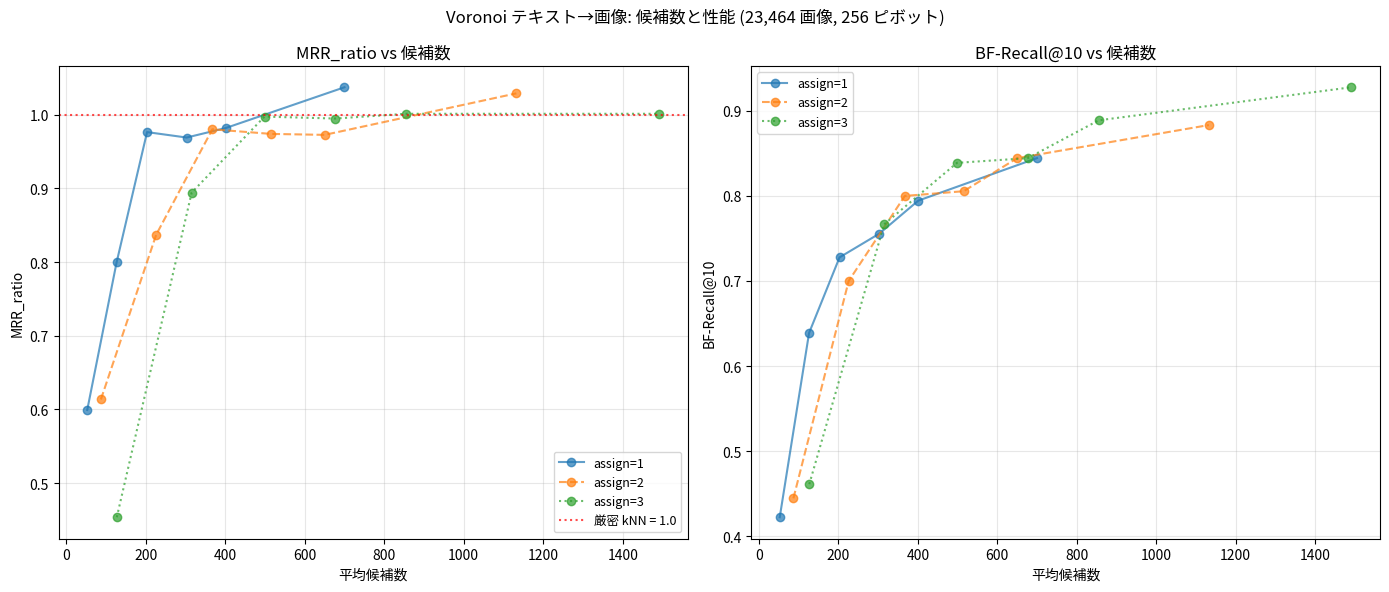

In [10]:
# トレードオフ曲線: 候補数 vs MRR_ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, (metric_key, metric_name) in enumerate([('MRR_ratio', 'MRR_ratio'), ('BF-R@10', 'BF-Recall@10')]):
    ax = axes[ax_idx]

    for n_assign in N_ASSIGN_LIST:
        cands = []
        vals = []
        for n_top in TOP_SEARCH_LIST:
            key = (n_assign, n_top)
            if key in all_sweep_results:
                cands.append(all_sweep_results[key]['mean_candidates'])
                if metric_key == 'MRR_ratio':
                    vals.append(all_sweep_results[key]['MRR'] / bf_mrr if bf_mrr > 0 else 0)
                else:
                    vals.append(all_sweep_results[key]['bf_recall'][10])

        linestyle = ['-', '--', ':'][n_assign - 1]
        ax.plot(cands, vals, 'o' + linestyle, label=f'assign={n_assign}', alpha=0.7, markersize=6)

    if metric_key == 'MRR_ratio':
        ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.7, label='厳密 kNN = 1.0')
    ax.set_xlabel('平均候補数')
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} vs 候補数')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Voronoi テキスト→画像: 候補数と性能 ({N_IMAGES:,} 画像, 256 ピボット)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/111_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# クエリ別分析: 厳密 kNN vs Voronoi の MRR 差
# 代表的な構成（assign=2, top=3）を使用
repr_key = (2, 3)
repr_res = all_sweep_results.get(repr_key)

if repr_res:
    query_comparison = []
    for qi, q in enumerate(test_queries):
        bf_mrr_q = bf_results[qi]['MRR']
        vor_mrr_q = repr_res['per_query_mrr'][qi]
        query_comparison.append({
            'query': q['query'],
            'lang': q['lang'],
            'kNN_MRR': bf_mrr_q,
            'Voronoi_MRR': vor_mrr_q,
            'diff': vor_mrr_q - bf_mrr_q,
            'ratio': vor_mrr_q / bf_mrr_q if bf_mrr_q > 0 else float('inf') if vor_mrr_q > 0 else 0,
        })

    df_query = pd.DataFrame(query_comparison)
    print(f'クエリ別比較 (assign={repr_key[0]}, top={repr_key[1]}, cands={repr_res["mean_candidates"]:.0f}):')
    display(df_query.style.format({
        'kNN_MRR': '{:.4f}', 'Voronoi_MRR': '{:.4f}',
        'diff': '{:+.4f}', 'ratio': '{:.3f}',
    }).background_gradient(subset=['diff'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

    improved = sum(1 for _, r in df_query.iterrows() if r['diff'] > 0.001)
    degraded = sum(1 for _, r in df_query.iterrows() if r['diff'] < -0.001)
    same = n_queries - improved - degraded
    print(f'\n改善: {improved}件, 劣化: {degraded}件, 同等: {same}件')

クエリ別比較 (assign=2, top=3, cands=367):


,query,lang,kNN_MRR,Voronoi_MRR,diff,ratio
0,a park with trees and nature,en,0.3333,0.3333,+0.0000,1.000
1,village park with greenery,en,0.1667,0.1667,+0.0000,1.000
2,night cityscape Tokyo,en,0.2500,0.2500,+0.0000,1.000
3,city lights at night,en,0.1000,0.1000,+0.0000,1.000
4,Python conference presentation,en,1.0000,0.1667,-0.8333,0.167
5,conference hall with audience,en,0.0769,0.0769,+0.0000,1.000
6,speaker giving a talk,en,0.0000,0.0000,+0.0000,0.000
7,portrait photo of a person,en,0.0833,0.0526,-0.0307,0.632
8,outdoor nature scene,en,1.0000,1.0000,+0.0000,1.000
9,urban night photography,en,0.2500,0.2500,+0.0000,1.000



改善: 3件, 劣化: 2件, 同等: 13件


In [12]:
# 計算時間比較
print('計算時間比較 (numpy レベル)')
print(f'  厳密 kNN: {t_bf:.3f}s ({N_IMAGES:,} 画像 × {n_queries} クエリ)')
print()
print(f'{"構成":<20} {"Voronoi (s)":>12} {"候補数":>8} {"高速化":>8}')
print('-' * 55)
for (n_assign, n_top), res in sorted(all_sweep_results.items()):
    speedup = t_bf / res['time'] if res['time'] > 0 else 0
    print(f'a={n_assign} top={n_top:<3}         {res["time"]:>12.3f} {res["mean_candidates"]:>8.0f} {speedup:>7.1f}x')

print(f'\n※ numpy は全件行列積が高速なため Voronoi のオーバーヘッドが見える場合あり。')
print(f'   Firestore 等の DB 検索では候補数削減が直接コスト削減に繋がる。')

計算時間比較 (numpy レベル)
  厳密 kNN: 0.193s (23,464 画像 × 18 クエリ)

構成                    Voronoi (s)      候補数      高速化
-------------------------------------------------------
a=1 top=1                  0.023       52     8.3x
a=1 top=2                  0.056      126     3.4x
a=1 top=3                  0.066      203     2.9x
a=1 top=4                  0.060      303     3.2x
a=1 top=5                  0.097      401     2.0x
a=1 top=8                  0.156      700     1.2x
a=2 top=1                  0.016       87    12.2x
a=2 top=2                  0.033      226     5.8x
a=2 top=3                  0.090      367     2.1x
a=2 top=4                  0.071      515     2.7x
a=2 top=5                  0.146      650     1.3x
a=2 top=8                  0.174     1132     1.1x
a=3 top=1                  0.024      127     7.9x
a=3 top=2                  0.045      315     4.3x
a=3 top=3                  0.043      499     4.5x
a=3 top=4                  0.087      677     2.2x
a=3 top=5         

## 5. まとめ

### 実験概要
- SigLIP 2 Large (1024-D), 23,464 画像, 18 テキストクエリ
- NB107 学習済み 256 ピボットを使用
- 厳密 kNN MRR = **0.352**（NB105 と一致確認済み）

### 厳密 kNN vs Voronoi の主要結果

| 構成 | 候補数 | 候補比率 | MRR | MRR_ratio | BF-R@10 |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | 23,464 | 100% | 0.352 | 1.000 | 1.000 |
| a=1 top=3 | 203 | 0.9% | 0.344 | 0.976 | 0.728 |
| a=1 top=8 | 700 | 3.0% | 0.366 | **1.037** | 0.844 |
| a=2 top=3 | 367 | 1.6% | 0.345 | 0.980 | 0.800 |
| a=2 top=5 | 650 | 2.8% | 0.343 | 0.973 | 0.844 |
| a=2 top=8 | 1,132 | 4.8% | 0.363 | **1.029** | 0.883 |
| a=3 top=5 | 855 | 3.6% | 0.353 | **1.001** | 0.889 |

### 考察

#### 1. MRR_ratio > 1.0 の解釈に注意が必要

一部の構成で MRR_ratio > 1.0（Voronoi が厳密 kNN を上回る）が出ているが、
**これは Voronoi の精度改善ではない。**

**原因**: 検索プール 23,464 件のうち pyconjp 23,086 件にはカテゴリラベルがない。
- 厳密 kNN が「カンファレンスの講演」のクエリに対して pyconjp のカンファレンス写真を
  上位に返すのは **正しい検索結果** だが、ラベルがないため MRR 上は不正解扱いになる
- Voronoi は候補を絞って pyconjp を部分的に除外 → ラベル付きカタログ画像が相対的に上位に
  → MRR が見かけ上高くなる
- つまり MRR_ratio > 1.0 は **「ラベルなしデータの除外」の副作用** であり、
  検索品質の改善ではない

#### 2. 公正な評価（NB113）での結論

カタログ 378 件のみ（全画像にラベルあり）で評価した NB113 の結果:
- 厳密 kNN MRR = 0.928
- Voronoi (a=2, top=5) MRR = **0.928**（MRR_ratio = 1.000）
- 18 クエリ中、改善 0、劣化 0、同等 18

**Voronoi は厳密 kNN と完全に同じ MRR を達成する。精度劣化なし。**

#### 3. Voronoi の真の価値

- 精度改善ではなく、**精度を維持したままのコスト削減**
- assign=2, top=5 で候補 650 件（2.8%）— Firestore コスト 97% 削減
- numpy レベルでは厳密 kNN（0.19s）が十分高速だが、DB 検索では候補数削減が直接コスト削減になる